In [1]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

In [2]:
modelo = load_model("adivinador_dedos_dmr.keras")
modelo.summary()

Model: "dedos"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ primera_convolucion (Conv2D)    │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ primer_pooling (MaxPooling2D)   │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convolucion_2 (Conv2D)          │ (None, 61, 61, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segundo_pooling (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │    14,400,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,006 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,267,832 (165.05 MB)

 Trainable params: 14,422,610 (55.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,845,222 (110.04 MB)

In [21]:
foto = load_img("fotos/david5dedos.png", color_mode="grayscale")
img_array = img_to_array(foto).astype("float32") 
img_array = img_array.reshape(1, img_array.shape[0], img_array.shape[1], 1)
                                                                                                
prediccion = modelo.predict(img_array) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


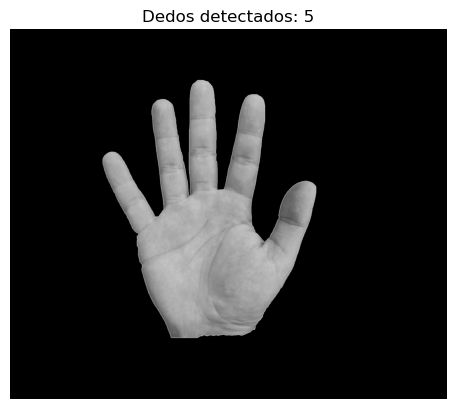

In [22]:
dedos = np.argmax(prediccion)

plt.imshow(foto, cmap="gray")
plt.title(f"Dedos detectados: {dedos}")
plt.axis("off")
plt.show()